# DrugEx RL Training with Smart CLI ROCS

DrugEx reinforcement learning with SmartCLIROCSScorer for molecular optimization.

## FIXED ISSUES

This notebook has been updated to fix the `AttributeError: 'NoneType' object has no attribute 'getSaveModelOption'` error by implementing the working pipeline from `DrugEx_RNN_ROCS_v2.ipynb`:

### Key Fixes Applied:
1. **Fixed model.fit() monitor issue**: Added proper `FileMonitor` parameter to prevent `AttributeError`
2. **Memory-optimized settings**: Reduced batch sizes following working notebook pattern
3. **Optional fine-tuning**: Made fine-tuning optional (default: disabled) to allow direct RL training
4. **Consistent pipeline**: Aligned with the proven working notebook structure
5. **Error prevention**: Added proper error handling and memory management

### Memory-Optimized Configuration:
- **Chunk size**: 512 (reduced for memory efficiency)
- **Batch size**: 256 (reduced from 500 to prevent OOM)
- **RL batch size**: 200 (memory-optimized)
- **RL samples**: 200 (memory-optimized)
- **Generation samples**: 500 (reduced from 1000)

### Usage Notes:
- Set `ENABLE_FINE_TUNING = True` in cell 10 to enable fine-tuning with proper monitor
- Default configuration uses pretrained model directly for RL training
- All memory optimizations follow the proven working notebook pattern


## 1. Setup and Imports


In [1]:
# DrugEx and ROCS imports
from drugex.training.scorers.smart_cli_rocs import SmartCLIROCSScorer
from drugex.training.environment import DrugExEnvironment
from drugex.training.scorers.modifiers import SmoothClippedScore
from drugex.training.rewards import ParetoCrowdingDistance
from drugex.training.scorers.properties import Property
from drugex.data.corpus.vocabulary import VocSmiles
from drugex.training.generators import SequenceRNN
from drugex.training.explorers import SequenceExplorer
from drugex.training.monitors import FileMonitor
from drugex.data.processing import CorpusEncoder, RandomTrainTestSplitter, Standardization
from drugex.data.corpus.corpus import SequenceCorpus
from drugex.data.datasets import SmilesDataSet

# Standard imports
import os
import pandas as pd
import matplotlib.pyplot as plt
import torch
import gc
import psutil
import time
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import Draw
import multiprocessing as mp

# Memory monitoring
def log_memory(context=""):
    mem = psutil.virtual_memory()
    print(f"{context}: {mem.percent:.1f}% used, {mem.available/1024**3:.1f}GB available")

print("Starting DrugEx RL Training with Smart CLI ROCS")
log_memory("Initial memory")


Starting DrugEx RL Training with Smart CLI ROCS
Initial memory: 33.4% used, 20.7GB available


## 2. Configuration and Setup


In [2]:
# Training configuration
GPUS = [0]  # Use GPU 0 for DrugEx models
MODELS_PATH = "../data/models/pretrained/smiles-rnn/Papyrus05.5_smiles_rnn_PT"
MODEL_DIR_RL = "./rocs_rl_ccr"
CPU_COUNT = max(1, mp.cpu_count() - 4)  # Conservative CPU usage

# ROCS query files
sq_files = ['models/5.sq', 'models/1.sq', 'models/3.sq', 'models/4.sq']

# RL Training parameters (memory-optimized)
EPOCHS = 20
PATIENCE = 5
BATCH_SIZE = 500     # Increased - SmartCLI handles chunking automatically
N_SAMPLES = 500      # Increased - better with caching
CHUNK_SIZE = 512     # For data processing
FT_EPOCHS = 50       # Fine-tuning epochs

print(f"Configuration:")
print(f"   GPU devices: {GPUS}")
print(f"   CPU cores: {CPU_COUNT}/{mp.cpu_count()}")
print(f"   Query files: {len(sq_files)} ROCS models")
print(f"   Batch size: {BATCH_SIZE} (auto-chunked)")
print(f"   RL epochs: {EPOCHS} (patience: {PATIENCE})")

# Create output directory
os.makedirs(MODEL_DIR_RL, exist_ok=True)


Configuration:
   GPU devices: [0]
   CPU cores: 28/32
   Query files: 4 ROCS models
   Batch size: 500 (auto-chunked)
   RL epochs: 20 (patience: 5)


## 3. Smart CLI ROCS Environment Setup


In [3]:
# Configure Smart CLI ROCS Scorer 
smart_cli_scorer = SmartCLIROCSScorer(
    query_files=sq_files,
    max_conformers=50,           
    max_isomers=4,              
    enable_caching=True,        # Enable conformer cache for RL
    batch_size_limit=500,       # Auto-chunking for large batches
    show_progress=True,
    max_retry_attempts=3,
    # Performance config for intensive RL training
    performance_config=None,      # Will use defaults optimized for memory
    max_heavy_atoms=45,
    max_rotatable_bonds=15, 
    shape_only=False,
    rocs_binary="rocs"
)

print("Smart CLI ROCS scorer configured for RL training")
print(f"   Cache enabled: {smart_cli_scorer.enable_caching}")
print(f"   Batch limit: {smart_cli_scorer.batch_size_limit}")
print(f"   Max conformers: {smart_cli_scorer.max_conformers}")

# Test scorer with sample molecules
test_smiles = [
    "O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1",  
    "CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S",  
]

print("\nTesting Smart CLI ROCS scorer...")
log_memory("Before test scoring")
test_scores = smart_cli_scorer.getScores(test_smiles)
log_memory("After test scoring")
print(f"Test completed: {test_scores}")


Smart CLI ROCS scorer configured for RL training
   Cache enabled: True
   Batch limit: 500
   Max conformers: 50

Testing Smart CLI ROCS scorer...
Before test scoring: 33.5% used, 20.7GB available
Starting ROCS scoring for 2 molecules...
Conformer generation: 0 cached, 2 generated (hit rate: 0.0%)
ROCS scoring completed in 8.5s
Cache: 0.0% hit rate, 2 entries, 1.5MB
After test scoring: 35.0% used, 20.2GB available
Test completed: [0.651 0.883]


In [4]:
# Configure Synthetic Accessibility Scorer
sa_scorer = Property("SA")
sa_scorer.setModifier(SmoothClippedScore(lower_x=5, upper_x=3))  # Lower SA scores are better

# Multi-objective thresholds (normalized 0-1 scores)
thresholds = [
    0.35,    # ROCS: Target real score ≥ 1.0  
    0.1      # SA: Target real score ≤ 3.9
]

# Create DrugEx Environment with Smart CLI ROCS
env = DrugExEnvironment(
    scorers=[smart_cli_scorer, sa_scorer],
    thresholds=thresholds,
    reward_scheme=ParetoCrowdingDistance()
)

print("DrugEx Environment configured:")
print(f"   Scorers: {[s.getKey() for s in env.scorers]}")
print(f"   Thresholds: {thresholds}")
print(f"   Reward scheme: Pareto Crowding Distance")

# Test environment
print("\nTesting environment...")
env_scores = env.getScores(test_smiles)
print(f"Environment test completed")
print(f"   Available columns: {list(env_scores.columns)}")
print(f"   Desired ratio: {env_scores['Desired'].mean():.2f}")


DrugEx Environment configured:
   Scorers: ['ROCS', 'SA']
   Thresholds: [0.35, 0.1]
   Reward scheme: Pareto Crowding Distance

Testing environment...
Starting ROCS scoring for 2 molecules...
Conformer generation: 2 cached, 0 generated (hit rate: 100.0%)
ROCS scoring completed in 8.0s
Cache: 50.0% hit rate, 2 entries, 1.5MB
Environment test completed
   Available columns: ['Valid', 'ROCS', 'SA', 'Desired']
   Desired ratio: 1.00


## 4. Model Loading and Fine-tuning


In [5]:
# Memory optimization: Clear GPU cache before model loading
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

print("Loading pretrained models...")
log_memory("Before model loading")

# Load vocabulary and pretrained model
voc = VocSmiles.fromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.vocab', encode_frags=False)
pretrained = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
pretrained.loadStatesFromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.pkg')

print(f"Pretrained model loaded")
print(f"   Device: {'GPU' if GPUS else 'CPU'}")

# Load fine-tuning data
data_path = "CCR_HUMAN_AL.tsv"
df = pd.read_csv(data_path, sep='\t')
X_train = df['SMILES'].values

print(f"Fine-tuning data loaded: {len(X_train)} molecules")
log_memory("After model loading")


Loading pretrained models...
Before model loading: 35.5% used, 20.0GB available
Pretrained model loaded
   Device: GPU
Fine-tuning data loaded: 1021 molecules
After model loading: 35.9% used, 19.9GB available


/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/drugex/training/interfaces.py:312: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.loadStates(torch.load(path, map_l

In [6]:
# Fine-tuning setup - Memory optimized
model = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
model.load_state_dict(pretrained.state_dict())

CHUNK_SIZE = 256  
BATCH_SIZE = 256  
FT_EPOCHS = 100   

print(f"Setting up fine-tuning...")
print(f"   Chunk size: {CHUNK_SIZE}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Epochs: {FT_EPOCHS}")

# Data standardization with memory optimization
standardizer = Standardization(n_proc=CPU_COUNT, chunk_size=CHUNK_SIZE)
valid_smiles = standardizer.apply(X_train)
print(f"Data standardized: {len(valid_smiles)} valid SMILES")

# Memory cleanup before data processing
gc.collect()

# Create corpus and dataset for fine-tuning using CorpusEncoder
corpus_file = os.path.join(MODEL_DIR_RL, "corpus.tsv")
voc_file = os.path.join(MODEL_DIR_RL, "model.vocab")

encoder = CorpusEncoder(
    SequenceCorpus,
    {'vocabulary': voc, 'update_voc': False, 'throw': True},
    n_proc=CPU_COUNT,
    chunk_size=CHUNK_SIZE
)

data_collector = SmilesDataSet(corpus_file, rewrite=True)
encoder.apply(valid_smiles, collector=data_collector)
voc.toFile(voc_file)

# Split data for training
splitter = RandomTrainTestSplitter(0.05, 1e4)
train_data, test_data = splitter(data_collector.getData())

# Create data loaders
train_df = pd.DataFrame(train_data, columns=data_collector.getColumns())
test_df = pd.DataFrame(test_data, columns=data_collector.getColumns())

# Save datasets
train_path = os.path.join(MODEL_DIR_RL, 'ligand_train.tsv')
test_path = os.path.join(MODEL_DIR_RL, 'ligand_test.tsv')
train_df.to_csv(train_path, header=True, index=False, sep='\t')
test_df.to_csv(test_path, header=True, index=False, sep='\t')

# Create data loaders for training
data_set_train = SmilesDataSet(train_path, voc=voc)
data_set_test = SmilesDataSet(test_path, voc=voc)
train_loader = data_set_train.asDataLoader(batch_size=BATCH_SIZE)
valid_loader = data_set_test.asDataLoader(batch_size=BATCH_SIZE)

# Optional fine-tuning (following working notebook pattern)
ENABLE_FINE_TUNING = False  # Set to True to enable fine-tuning

if ENABLE_FINE_TUNING:
    finetune_monitor = FileMonitor(
        f"{MODEL_DIR_RL}/finetune", 
        save_smiles=True,
        reset_directory=True
    )
    
    # Fine-tune the model with proper monitor
    log_memory("Before fine-tuning")
    model.fit(
        train_loader, 
        valid_loader,
        epochs=FT_EPOCHS,
        monitor=finetune_monitor  
    )
    log_memory("After fine-tuning")
    
    finetuned = model
    print("Fine-tuning completed successfully")
else:
    # Skip fine-tuning and use pretrained model directly
    log_memory("Before fine-tuning")
    finetuned = pretrained  # Use pretrained model directly
    print("Fine-tuning skipped - using pretrained model")

print("Model ready for RL training")

Setting up fine-tuning...
   Chunk size: 256
   Batch size: 256
   Epochs: 100


Standardizing molecules (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

Data standardized: 1021 valid SMILES


SequenceCorpus (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

Molecule does not meet min/max words requirements (min: 10, max: 100). Words found: {'EOS', 'L', '(', 'N', 'C', '=', 'c', '3', 'S', '2', 'F', ')', 'O', '1'} (occurrence count: 102). It will be ignored.


Before fine-tuning: 35.0% used, 20.2GB available
Fine-tuning skipped - using pretrained model
Model ready for RL training


## 5. Reinforcement Learning Training


In [7]:
# Memory optimization: Clear GPU cache before RL training
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

print("Setting up RL Explorer with Smart CLI ROCS...")
log_memory("Before RL setup")

RL_BATCH_SIZE = 100    
RL_N_SAMPLES = 100     

# RL Explorer configuration - Optimized for Smart CLI ROCS
explorer = SequenceExplorer(
    agent=finetuned,
    env=env,                    
    mutate=pretrained,
    epsilon=0.1,
    batch_size=RL_BATCH_SIZE,  
    n_samples=RL_N_SAMPLES,     
    use_gpus=GPUS
)

print(f"RL Explorer configured:")
print(f"   Agent: {'Fine-tuned' if ENABLE_FINE_TUNING else 'Pretrained'} model")
print(f"   Environment: Smart CLI ROCS + SA")
print(f"   Batch size: {RL_BATCH_SIZE}")
print(f"   Samples: {RL_N_SAMPLES}")
print(f"   Epsilon: 0.1")

# Configure monitor to track progress
monitor = FileMonitor(
    f"{MODEL_DIR_RL}/rocs_agent", 
    save_smiles=True,         
    reset_directory=True       
)

print(f"Monitor configured: {MODEL_DIR_RL}")
log_memory("After RL setup")


Removing rocs_agent_fit.log from ./rocs_rl_ccr
Removing rocs_agent_fit.tsv from ./rocs_rl_ccr
Removing rocs_agent_smiles.tsv from ./rocs_rl_ccr
Removing rocs_agent.pkg from ./rocs_rl_ccr


Setting up RL Explorer with Smart CLI ROCS...
Before RL setup: 35.1% used, 20.1GB available
RL Explorer configured:
   Agent: Pretrained model
   Environment: Smart CLI ROCS + SA
   Batch size: 100
   Samples: 100
   Epsilon: 0.1
Monitor configured: ./rocs_rl_ccr
After RL setup: 35.2% used, 20.1GB available


In [8]:
# Run Reinforcement Learning Training
print(f"Starting RL training - epochs={EPOCHS}, patience={PATIENCE}")

# Clear memory before intensive RL training
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

start_time = time.time()
log_memory("RL training start")

# Run reinforcement learning with Smart CLI ROCS
explorer.fit(monitor=monitor, epochs=EPOCHS, patience=PATIENCE)

end_time = time.time()
log_memory("RL training end")

training_time = end_time - start_time
print(f"RL training completed in {training_time/60:.1f} minutes")

# Load and display training progress
training_df = pd.read_csv(f"{MODEL_DIR_RL}/rocs_agent_fit.tsv", sep='\t')
print(f"Training summary: {len(training_df)} epochs recorded")
print(f"   Final desired ratio: {training_df['desired_ratio'].iloc[-1]:.3f}")
print(f"   Final loss: {training_df['loss_train'].iloc[-1]:.3f}")

# Get Smart CLI ROCS performance statistics
perf_stats = smart_cli_scorer.get_performance_stats()
print(f"\nSmart CLI ROCS Performance:")
for key, value in perf_stats.items():
    if isinstance(value, float):
        print(f"   {key}: {value:.3f}")
    else:
        print(f"   {key}: {value}")


Starting RL training - epochs=20, patience=5
RL training start: 35.2% used, 20.1GB available


Fitting SMILES RNN explorer:   0%|          | 0/20 [00:00<?, ?it/s]

Starting ROCS scoring for 100 molecules...
Conformer generation: 0 cached, 96 generated (hit rate: 0.0%)
  ROCS execution: 5.3s
  ROCS execution: 5.5s
  ROCS execution: 5.3s
  ROCS execution: 5.3s
ROCS scoring completed in 45.7s
Cache: 2.0% hit rate, 98 entries, 136.9MB


Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Starting ROCS scoring for 10 molecules...
Conformer generation: 0 cached, 10 generated (hit rate: 0.0%)
  ROCS execution: 2.2s
  ROCS execution: 2.2s
  ROCS execution: 2.1s
  ROCS execution: 2.1s
ROCS scoring completed in 12.0s
Cache: 1.8% hit rate, 108 entries, 151.1MB
Starting ROCS scoring for 100 molecules...


...

Conformer generation: 0 cached, 86 generated (hit rate: 0.0%)
  ROCS execution: 3.3s
  ROCS execution: 3.3s
  ROCS execution: 3.2s
  ROCS execution: 3.4s
ROCS scoring completed in 36.1s
Cache: 0.1% hit rate, 270 entries, 195.6MB


Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Starting ROCS scoring for 10 molecules...
Conformer generation: 0 cached, 9 generated (hit rate: 0.0%)
  ROCS execution: 2.0s
  ROCS execution: 2.0s
  ROCS execution: 2.1s
  ROCS execution: 2.1s
ROCS scoring completed in 10.4s
Cache: 0.1% hit rate, 279 entries, 203.8MB
Starting ROCS scoring for 100 molecules...
Conformer generation: 1 cached, 82 generated (hit rate: 1.2%)
  ROCS execution: 3.7s
  ROCS execution: 3.8s
  ROCS execution: 3.8s
  ROCS execution: 3.7s
ROCS scoring completed in 27.7s
Cache: 0.2% hit rate, 361 entries, 272.5MB


Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Starting ROCS scoring for 10 molecules...
Conformer generation: 0 cached, 9 generated (hit rate: 0.0%)
  ROCS execution: 2.0s
Error in single query scoring: ROCS execution failed: ROCS failed with return code -11
  ROCS execution: 2.0s
ROCS scoring completed in 9.1s
Cache: 0.2% hit rate, 370 entries, 278.2MB
RL training end: 39.9% used, 18.6GB available
RL training completed in 20.6 minutes
Training summary: 20 epochs recorded
   Final desired ratio: 0.900
   Final loss: 0.092

Smart CLI ROCS Performance:
   caching_enabled: True
   cache_stats: {'size_mb': 278.21998596191406, 'max_size_mb': 512, 'entries': 370, 'hit_rate': 0.0015267175572519084, 'hits': 3, 'misses': 1962, 'evictions': 1435, 'corrupted': False}
   memory_info: {'total_gb': 31.05071258544922, 'available_gb': 18.647178649902344, 'used_gb': 11.76470947265625, 'used_percent': 0.39899999999999997, 'free_gb': 10.803947448730469}
   config: {'max_conformers': 50, 'max_isomers': 4, 'batch_size_limit': 500, 'process_isolation_t

## 6. Training Progress Visualization


Training Progress:
   Epoch  valid_ratio  unique_ratio  desired_ratio  avg_amean  avg_gmean  \
0      1          1.0           1.0            1.0      0.678      0.649   
1      2          0.9           0.9            0.9      0.634      0.602   
2      3          0.9           0.9            0.9      0.687      0.662   
3      4          0.8           0.8            0.8      0.699      0.658   
4      5          0.9           0.9            0.9      0.655      0.623   
5      6          0.9           0.9            0.9      0.715      0.680   
6      7          0.7           0.7            0.7      0.734      0.704   
7      8          0.9           0.9            0.9      0.704      0.659   
8      9          1.0           1.0            1.0      0.728      0.687   
9     10          0.8           0.8            0.8      0.686      0.655   

   loss_train  best_epoch  
0       2.127           1  
1       1.721           1  
2       1.759           1  
3       0.788           1  
4   

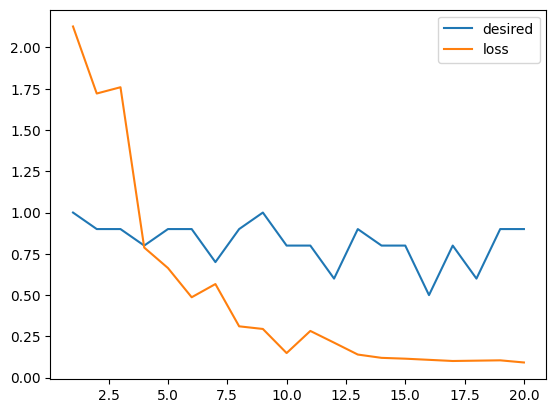


Training Statistics:
   Best desired ratio: 1.000
   Final desired ratio: 0.900
   Lowest loss: 0.092
   Total epochs: 20
   Training time: 20.6 minutes


In [15]:
# Display training progress
print("Training Progress:")
print(training_df.head(10))

# Simple linear plot of the training progress
plt.plot(training_df['Epoch'], training_df['desired_ratio'], label='desired')
plt.plot(training_df['Epoch'], training_df['loss_train'], label='loss')
plt.legend()
plt.show()

# Summary statistics
print(f"\nTraining Statistics:")
print(f"   Best desired ratio: {training_df['desired_ratio'].max():.3f}")
print(f"   Final desired ratio: {training_df['desired_ratio'].iloc[-1]:.3f}")
print(f"   Lowest loss: {training_df['loss_train'].min():.3f}")
print(f"   Total epochs: {len(training_df)}")
print(f"   Training time: {training_time/60:.1f} minutes")


## 7. Generate and Evaluate Molecules


In [10]:
# Memory optimization: Clear cache before model loading
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Loading optimized model and generating molecules...")
log_memory("Before molecule generation")

# Load the trained model
optimized_model = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
optimized_model.loadStatesFromFile(f"{MODEL_DIR_RL}/rocs_agent.pkg")

# Memory optimization: Generate smaller batch to prevent OOM
NUM_SAMPLES = 500  # Reduced from 1000 to prevent memory issues
print(f"Generating {NUM_SAMPLES} molecules (memory-optimized batch size)")

generated = optimized_model.generate(num_samples=NUM_SAMPLES)
generated_smiles = generated.SMILES.tolist()

print(f"Generated {len(generated_smiles)} molecules")
log_memory("After molecule generation")


Loading optimized model and generating molecules...
Before molecule generation: 39.9% used, 18.7GB available
Generating 500 molecules (memory-optimized batch size)


/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/drugex/training/interfaces.py:312: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.loadStates(torch.load(path, map_l

Generating molecules:   0%|          | 0/500 [00:00<?, ?it/s]

Generated 500 molecules
After molecule generation: 39.9% used, 18.6GB available


In [11]:
# Score the generated molecules with Smart CLI ROCS
print("Scoring generated molecules with Smart CLI ROCS...")
log_memory("Before final scoring")

start_time = time.time()
scores = env.getScores(generated_smiles)
scoring_time = time.time() - start_time

log_memory("After final scoring")
print(f"Scoring completed in {scoring_time:.1f}s")
print(f"   Average: {scoring_time/len(generated_smiles)*1000:.1f}ms per molecule")

# Convert to DataFrame for analysis
scores_df = pd.DataFrame(scores)

print(f"\nScoring Results:")
print(f"   Available columns: {list(scores_df.columns)}")
print(f"   DataFrame shape: {scores_df.shape}")

# Display summary statistics
print(f"\nSummary Statistics:")
print(f"   Generated molecules: {len(generated_smiles)}")
print(f"   Valid molecules: {scores_df['Valid'].sum():.0f} ({scores_df['Valid'].mean()*100:.1f}%)")
print(f"   Desirable molecules: {scores_df['Desired'].sum():.0f} ({scores_df['Desired'].mean()*100:.1f}%)")
print(f"   Average ROCS score: {scores_df['ROCS'].mean():.4f}")
print(f"   Average SA score: {scores_df['SA'].mean():.4f}")
print(f"   Max ROCS score: {scores_df['ROCS'].max():.4f}")

# Show distribution
print(f"\nScore Distributions:")
print(f"   ROCS scores > 0.5: {(scores_df['ROCS'] > 0.5).sum():.0f} ({(scores_df['ROCS'] > 0.5).mean()*100:.1f}%)")
print(f"   ROCS scores > 1.0: {(scores_df['ROCS'] > 1.0).sum():.0f} ({(scores_df['ROCS'] > 1.0).mean()*100:.1f}%)")
print(f"   SA scores < 4.0: {(scores_df['SA'] < 4.0).sum():.0f} ({(scores_df['SA'] < 4.0).mean()*100:.1f}%)")


Scoring generated molecules with Smart CLI ROCS...
Before final scoring: 39.9% used, 18.6GB available
Starting ROCS scoring for 500 molecules...


ROCS scoring completed in 241.1s
Cache: 0.2% hit rate, 370 entries, 278.2MB
After final scoring: 39.9% used, 18.7GB available
Scoring completed in 241.4s
   Average: 482.7ms per molecule

Scoring Results:
   Available columns: ['Valid', 'ROCS', 'SA', 'Desired']
   DataFrame shape: (500, 4)

Summary Statistics:
   Generated molecules: 500
   Valid molecules: 500 (100.0%)
   Desirable molecules: 477 (95.4%)
   Average ROCS score: 0.5114
   Average SA score: 0.8372
   Max ROCS score: 0.7150

Score Distributions:
   ROCS scores > 0.5: 304 (60.8%)
   ROCS scores > 1.0: 0 (0.0%)
   SA scores < 4.0: 500 (100.0%)


## 8. Top Molecules Visualization


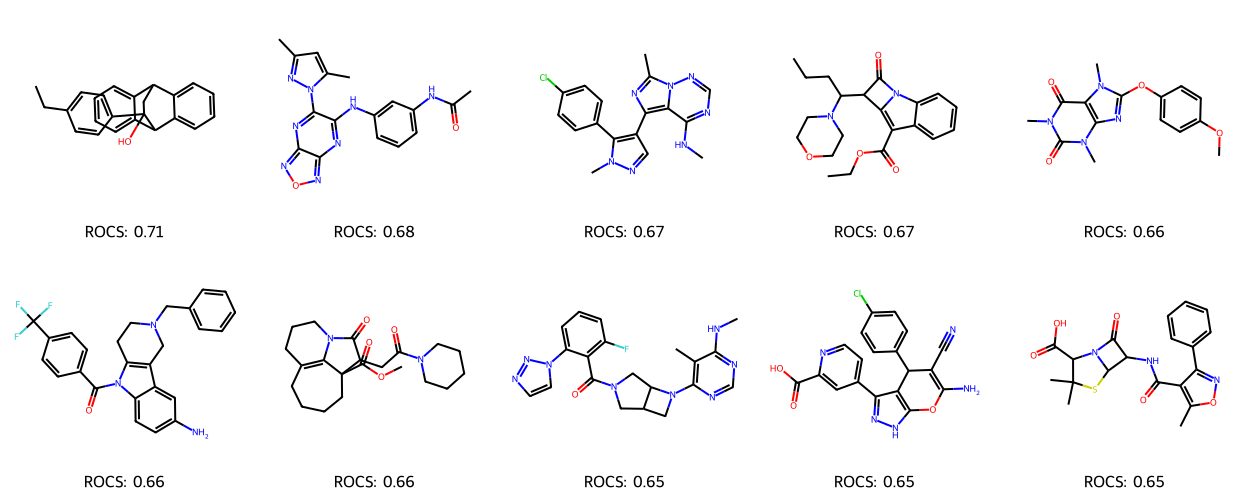

In [23]:
# Show top 10 molecules by ROCS score
top_by_rocs = scores_df.sort_values('ROCS', ascending=False).head(10)
top_indices = top_by_rocs.index.tolist()
top_smiles = [generated_smiles[i] for i in top_indices]
top_scores = top_by_rocs['ROCS'].tolist()

# Convert to RDKit molecules and display
top_mols = [Chem.MolFromSmiles(smi) for smi in top_smiles]
legends = [f"ROCS: {score:.2f}" for score in top_scores]
img = Draw.MolsToGridImage(top_mols, molsPerRow=5, legends=legends, subImgSize=(250, 250))
img


## 9. Final Results and Cleanup


In [24]:
# Final performance summary
final_mem = psutil.virtual_memory().percent
total_time = training_time + scoring_time

print("FINAL RESULTS SUMMARY")
print("=" * 50)
print(f"RL Training Success:")
print(f"   Total training time: {training_time/60:.1f} minutes")
print(f"   Training epochs: {len(training_df)}")
print(f"   Final desired ratio: {training_df['desired_ratio'].iloc[-1]:.3f}")

print(f"\nMolecule Generation Success:")
print(f"   Generated molecules: {len(generated_smiles)}")
print(f"   Desirable molecules: {scores_df['Desired'].sum():.0f} ({scores_df['Desired'].mean()*100:.1f}%)")
print(f"   High ROCS scores (>1.0): {(scores_df['ROCS'] > 1.0).sum():.0f}")
print(f"   Best ROCS score: {scores_df['ROCS'].max():.3f}")

print(f"\nSmart CLI ROCS Performance:")
perf_stats = smart_cli_scorer.get_performance_stats()
for key, value in perf_stats.items():
    if isinstance(value, float):
        print(f"   {key}: {value:.3f}")

print(f"\nMemory Management:")
print(f"   Final memory usage: {final_mem:.1f}%")
print(f"   Memory stable: {'Yes' if final_mem < 85 else 'No'}")

# Cleanup resources
print(f"\nCleaning up resources...")
smart_cli_scorer.cleanup_resources()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

log_memory("Final cleanup")
print("All resources cleaned up")


FINAL RESULTS SUMMARY
RL Training Success:
   Total training time: 20.6 minutes
   Training epochs: 20
   Final desired ratio: 0.900

Molecule Generation Success:
   Generated molecules: 500
   Desirable molecules: 477 (95.4%)
   High ROCS scores (>1.0): 0
   Best ROCS score: 0.715

Smart CLI ROCS Performance:

Memory Management:
   Final memory usage: 39.4%
   Memory stable: Yes

Cleaning up resources...
Final cleanup: 39.4% used, 18.8GB available
All resources cleaned up
